In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [2]:
img     = cv2.imread("test.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


In [3]:
# prepare image
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
_, thresh = cv2.threshold(blurred, 0, 255,
                          cv2.THRESH_BINARY + cv2.THRESH_OTSU)


In [4]:
#find Contour
contours, _ = cv2.findContours(thresh,
                                cv2.RETR_EXTERNAL,
                                cv2.CHAIN_APPROX_SIMPLE)
print(f"✅number of Contours: {len(contours)}")

# draw Contours + Bounding Boxes
img_contours = img_rgb.copy()
img_boxes    = img_rgb.copy()
img_shapes   = img_rgb.copy()

cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 2)

def detect_shape(contour):
    perimeter = cv2.arcLength(contour, True)
    approx    = cv2.approxPolyDP(contour, 0.04 * perimeter, True)
    corners   = len(approx)
    if corners == 3:   return "Triangle"
    elif corners == 4:
        x, y, w, h = cv2.boundingRect(approx)
        ratio = w / float(h)
        return "Square" if 0.9 <= ratio <= 1.1 else "Rectangle"
    elif corners > 8:  return "Circle"
    else:              return f"Polygon-{corners}"

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 500:        #ignore small Contour
        continue

    # Bounding Box
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(img_boxes, (x, y), (x+w, y+h), (255, 0, 0), 2)

    # اكتشاف الشكل واكتب اسمه
    shape = detect_shape(cnt)
    cx    = x + w // 2
    cy    = y + h // 2
    cv2.putText(img_shapes, shape,
                (cx - 40, cy),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6, (255, 0, 0), 2)
    cv2.drawContours(img_shapes, [cnt], -1, (0, 255, 0), 2)


✅ عدد الـ Contours: 263


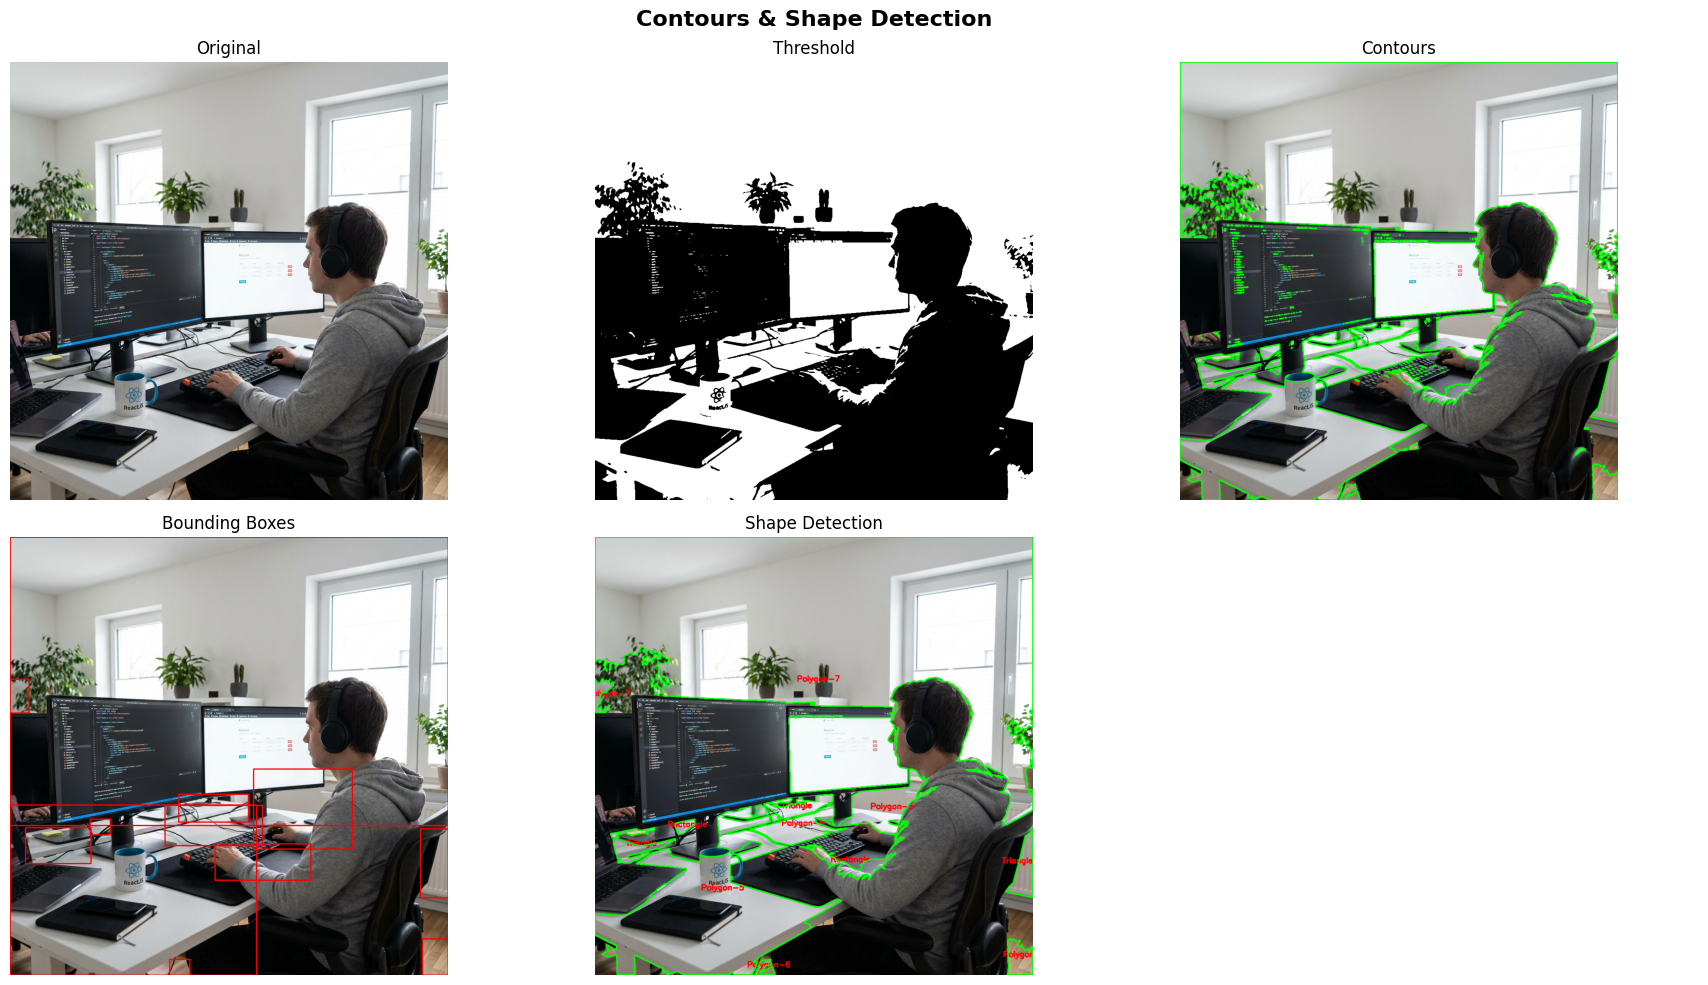

In [5]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Contours & Shape Detection", fontsize=16, fontweight="bold")

data = [
    (img_rgb,       "Original",        None),
    (thresh,        "Threshold",       "gray"),
    (img_contours,  "Contours",        None),
    (img_boxes,     "Bounding Boxes",  None),
    (img_shapes,    "Shape Detection", None),
]

for ax, (image, title, cmap) in zip(axes.flat, data):
    ax.imshow(image, cmap=cmap)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

axes[1][2].axis("off")   # الخانة الأخيرة فاضية

plt.tight_layout()
plt.show()

In [6]:
# عد كل الأشكال في الصورة
from collections import Counter

shape_counts = Counter()

for cnt in contours:
    if cv2.contourArea(cnt) < 500:
        continue
    shape = detect_shape(cnt)
    shape_counts[shape] += 1

print("\n📊 الأشكال في الصورة:")
for shape, count in shape_counts.items():
    print(f"   {shape}: {count}")


📊 الأشكال في الصورة:
   Polygon-6: 2
   Polygon-5: 3
   Rectangle: 2
   Triangle: 3
   Polygon-7: 2
